# Fixing levels

In [7]:
# %% Libraries
import os
import scanpy as sc
from pathlib import Path

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% object versions
COMB_V= 'refined-clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'

In [8]:
# load comb obj
comb = sc.read_h5ad(COMB_PATH)

## Level 3

In [9]:
# %% Map clusters to cell types (ct_resolvi)

leiden_resolvi_map = {
    # epithelial
    "7": "BC",
    "15": "SC",
    "12": "MCC",
    "21": "Gob",
    "19": "AT1",
    "13": "AT2",

    # LYM
    "4": "T",
    "1": "B",
    "9": "PC_IgA", # plasma IGHA1
    "17": "PC_IgA", # plasma IGHA1
    "11": "PC_IgM", # plasma IGHM
    "20": "PC_IgG", # plasma IGHG1/2
    "16": "PC_IgG", # plasma IGHG1/2
    "22": "PC_IgAG", # plasma mixed cluster

    # MYE
    "3": "Neut",
    "5": "Mast",
    "18": "AlvMac",
    "8": "Mac",

    # STROMA
    "6": "Fib",
    "14": "actFib", # POSTN activated 
    "2": "SMC", # smooth muscle cells

    # Endothelial
    "10": "EC",

    # ambiguous
    "0": "Amb",
    "23": "Amb",
}

RESOLVI_CT_KEY = 'ct_resolvi'
RESOLVI_CLUSTERS_KEY = 'leiden_resolvi_1.0'
comb.obs['ct_resolvi'] = comb.obs[RESOLVI_CLUSTERS_KEY].map(leiden_resolvi_map).astype('category')

# %% Rename classes (LEVEL 3) - same as ct_resolvi
comb.obs['ann_lvl_3'] = comb.obs['ct_resolvi']


## Level 2

In [21]:
# %% Rename classes (LEVEL 2)

map_lvl_2 = {
    # airway epithelium 
    'BC': 'AIR_EPI',
    'Club': 'AIR_EPI',
    'MCC': 'AIR_EPI',
    'Gob': 'AIR_EPI',
    'Hillock': 'AIR_EPI',
    'Deu': 'AIR_EPI',
    # alveolar epithelium
    'AT1': 'ALV_EPI',
    'AT2': 'ALV_EPI',
    # Lymphoid
    'CD4_T': 'LYM',
    'CD8_T': 'LYM',
    'cLym': 'LYM',
    'B': 'LYM',
    'cB': 'LYM',
    'PC_K_IgA': 'LYM',
    'PC_K_IgG': 'LYM',
    'PC_K_IgM': 'LYM',
    'PC_L_IgA': 'LYM',
    'PC_L_IgG': 'LYM',
    'PC_K_IgAG': 'LYM',
    # MYE
    'Neut': 'MYE',
    'Mast': 'MYE',
    'Mac': 'MYE',
    'AlvMac': 'MYE',
    # STROMAL
    'Fib': 'STROMA',
    'actFib': 'STROMA',
    'SMC': 'STROMA',
    # endothelial
    'EC': 'EC',
    'lymEC': 'EC',
    # Ambiguous
    "Amb": "AMB",
}

comb.obs['ann_lvl_2'] = comb.obs['ann_lvl_3_refined'].map(map_lvl_2).astype('category')

## Level 1

In [22]:
# %% Rename classes (LEVEL 1)

map_lvl_1 = {
    # epithelial 
    'AIR_EPI': 'EPI',
    'ALV_EPI': 'EPI',
    # immune
    'LYM': 'IMMUNE',
    'MYE': 'IMMUNE',
    # STROMAl
    'STROMA': 'STROMA',
    # endothelial
    'EC': 'EC',
    # Ambiguous
    "AMB": "AMB",
}

comb.obs['ann_lvl_1'] = comb.obs['ann_lvl_2'].map(map_lvl_1).astype('category')


## Check in UMAP

[<Axes: title={'center': 'leiden_resolvi_1.0'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'ann_lvl_3_refined'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'ann_lvl_2'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'ann_lvl_1'}, xlabel='UMAP1', ylabel='UMAP2'>]

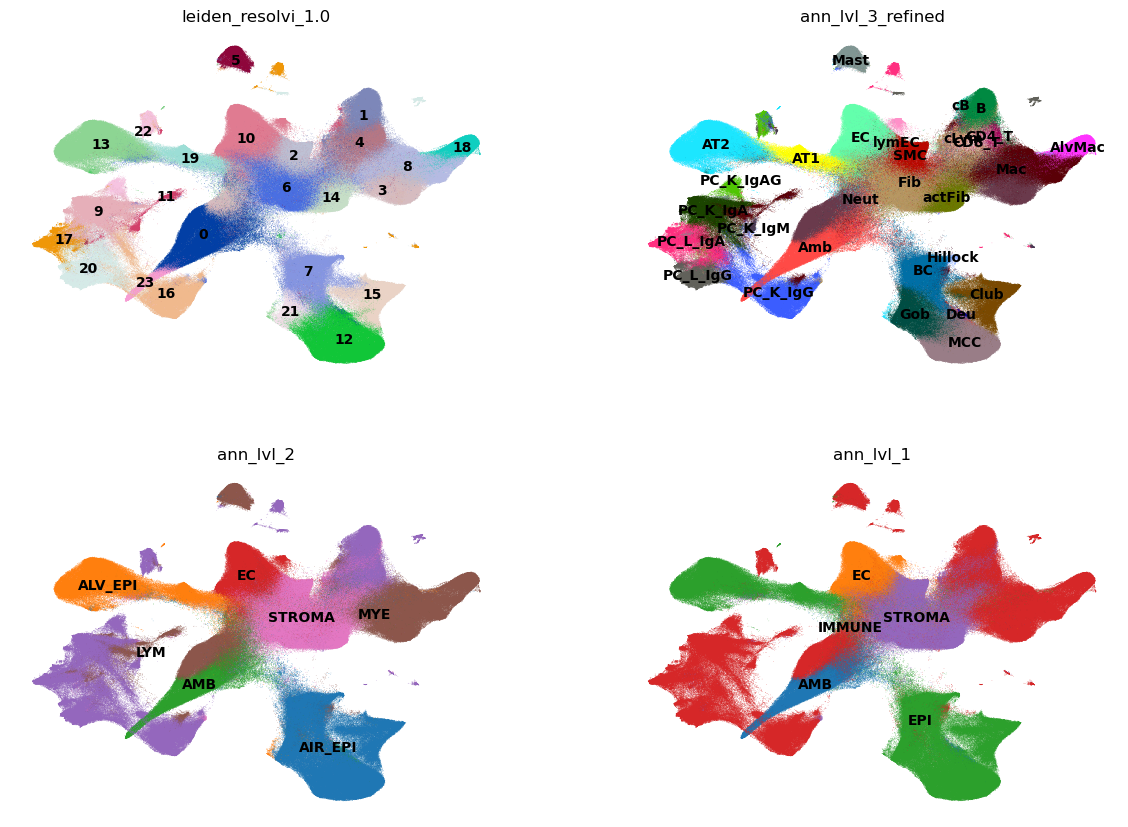

In [23]:
sc.pl.umap(
    comb,
    color=[RESOLVI_CLUSTERS_KEY, 'ann_lvl_3_refined', 'ann_lvl_3', 'ann_lvl_2', 'ann_lvl_1'],
    size=0.5,
    frameon=False,
    legend_loc='on data',
    return_fig = False,
    show=False,
    ncols=2
)

## Save annotations

In [24]:
# %% Save object
comb.write_h5ad(COMB_PATH)